In [10]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount

fourier_learners_cache_dir = Path("fourier_learners_cache")
ground_state_cache_dir = Path("groundstates")

experiment_dir = Path("experiments/kagome-24-fourier-full-2023-01-24")
accuracy_file = experiment_dir / f"acc-0.7-terms.csv"


def total_hamming_weight(analyzer: BooleanFourierAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["analyzer"]
        .truncate(keep_largest_n(row["terms"]))
        .prediction_score(scorer=scorer, max_batch_size=10000)
        for _, row in tqdm(df.iterrows())
    ]


In [2]:
%matplotlib inline

In [3]:
lattices = {height: KagomeLattice(width=2, height=height) for height in [2, 3, 4]}


In [ ]:
analyzers: dict[tuple[int, float, str], BooleanFourierAnalyzer] = {}
for height, J2, signal_kind in product(
    [2, 3, 4],
    [
        0.0,
        0.8,
        0.3,
        0.9,
        0.5,
        0.7,
        1.0,
        0.6,
        0.4,
        0.2,
        0.1,
        0.55,
        0.65,
        0.75,
        0.85,
        0.95,
        0.52,
        0.522,
        0.524,
        0.526,
        0.528,
    ],
    [AmplitudeMedianBinSignalKind(), SignSignalKind()],
):
    analyzer = BooleanFourierAnalyzer(
        system=HeisenbergJ1J2(
            lat=lattices[height],
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=ground_state_cache_dir,
            show_progress=True,
        ),
        use_subset_symmetries=True,
        show_progress=True,
        cache_dir=fourier_learners_cache_dir,
    )
    train_set = analyzer.system.canonical_basis.states
    try:
        analyzer.fit(train_set, signal_opt=SignalOption(kind=signal_kind), from_cache_only=True)
        analyzers[height, J2, signal_kind.name] = analyzer
    except ValueError as e:
        print(f"Failed to load {height, J2, signal_kind.name} from cache")
        print(f"Error: {e}")


In [7]:
terms_df = pd.read_csv(accuracy_file)


In [8]:
analyzers_df = (
    pd.Series(analyzers, name="analyzer")
    .to_frame()
    .reset_index()
    .rename(columns={"level_0": "height", "level_1": "J2", "level_2": "signal_kind"})
    .merge(terms_df, on=["height", "J2", "signal_kind"], how="left")
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["analyzer"], row["terms"]), axis=1
        ),
        number_spins=lambda df: df["analyzer"].apply(lambda a: a.system.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["height", "J2", "signal_kind"])
)


In [16]:
analyzers_df["sign_overlap"] = get_score_column(analyzers_df, scorer="sign_overlap")
# analyzers_df['accuracy']=get_score_column(analyzers_df, scorer="accuracy")


125it [21:21, 10.25s/it]


In [17]:
analyzers_df


analyzer  \
height J2    signal_kind                                                               
2      0.000 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
             sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.800 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
             sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.300 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
...                                                                              ...   
4      0.524 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
             sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.526 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
             sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.528 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   

                                   terms  hamming_weight  number_spins  \
height J2    signal_kind                                                 
2      0.000 amplitude_median_bin      2               8            12   
             sign                      1               4            12   
       0.800 amplitude_median_bin      5              18            12   
             sign                      2              10            12   
       0.300 amplitude_median_bin      2               8            12   
...                                  ...             ...           ...   
4      0.524 amplitude_median_bin     11              26            24   
             sign                     31             354            24   
       0.526 amplitude_median_bin     11              26            24   
             sign                     31             354            24   
       0.528 sign                     31             352            24   

                                     mean_hw  sign_overlap  
height J2    signal_kind                                    
2      0.000 amplitude_median_bin   4.000000      0.175253  
             sign                   4.000000      1.000000  
       0.800 amplitude_median_bin   3.600000      0.833403  
             sign                   5.000000      0.665067  
       0.300 amplitude_median_bin   4.000000      0.107206  
...                                      ...           ...  
4      0.524 amplitude_median_bin   2.363636      0.996395  
             sign                  11.419355      0.902306  
       0.526 amplitude_median_bin   2.363636      0.996406  
             sign                  11.419355      0.899007  
       0.528 sign                  11.354839      0.889471  

[125 rows x 6 columns]

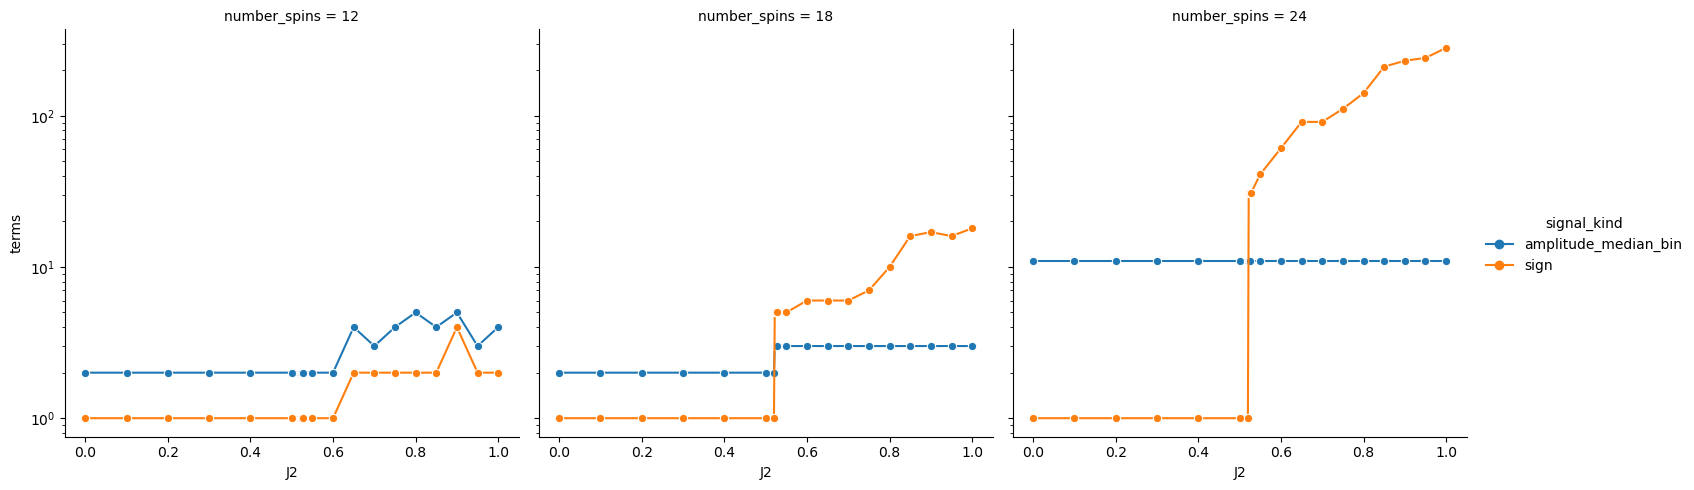

In [20]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


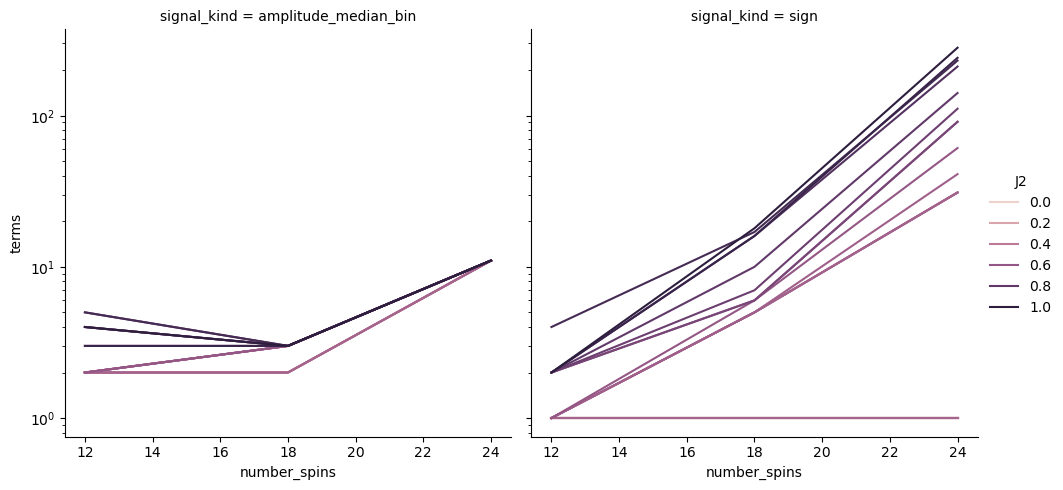

In [21]:
sns.relplot(
    analyzers_df.reset_index(),
    # .assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [22]:
def plot_subsets(subsets, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset in zip(axes[0], subsets):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
    return fig


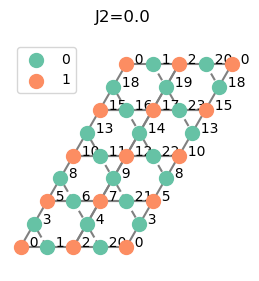

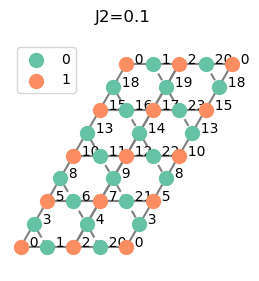

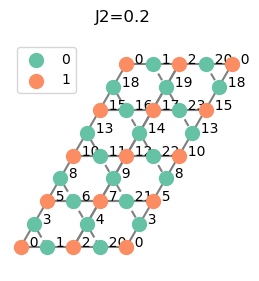

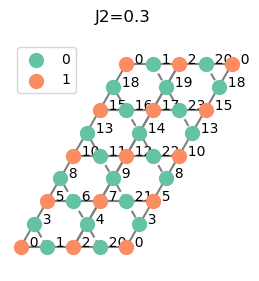

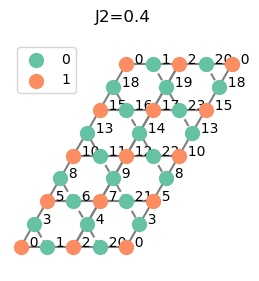

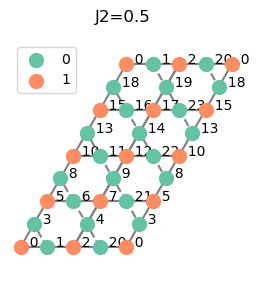

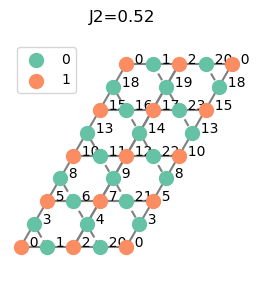

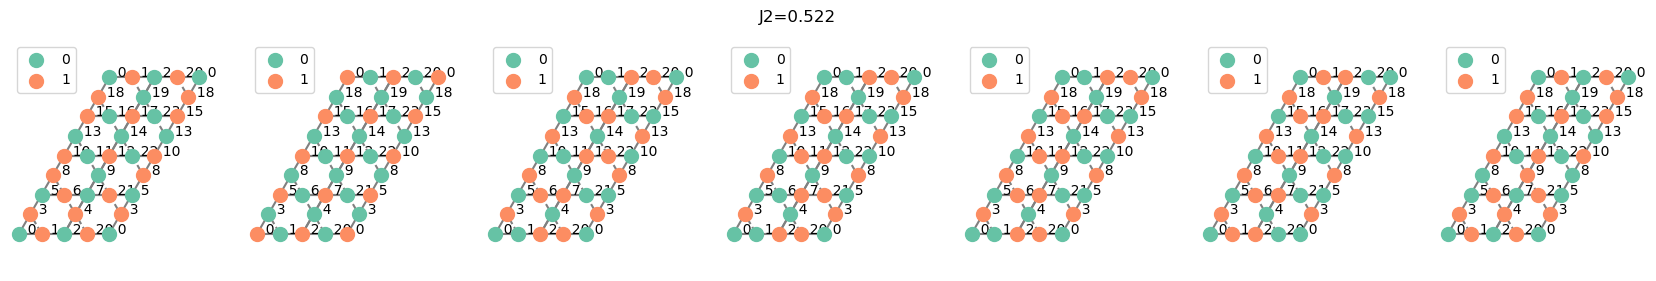

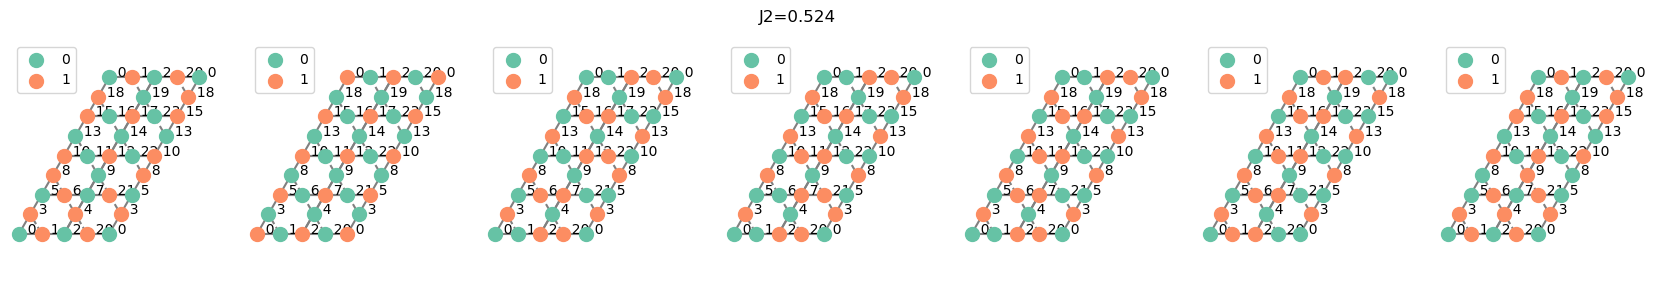

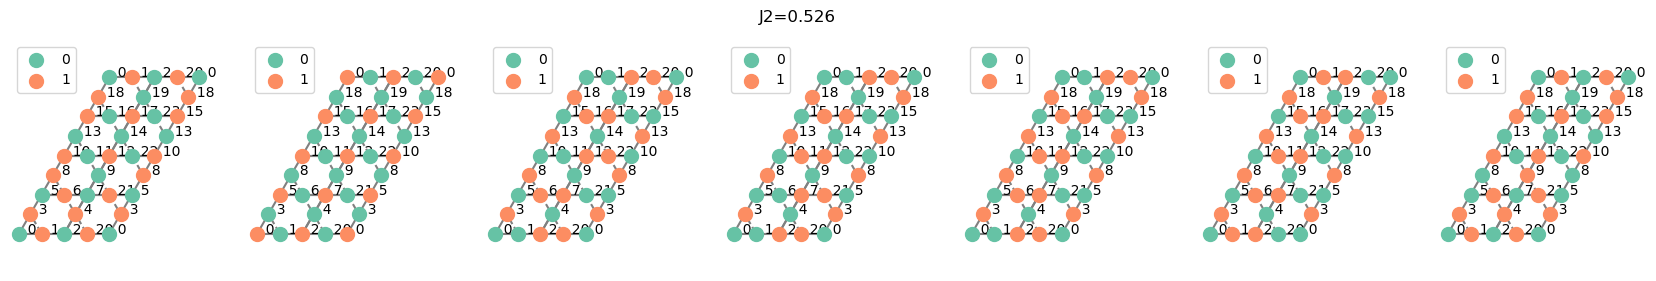

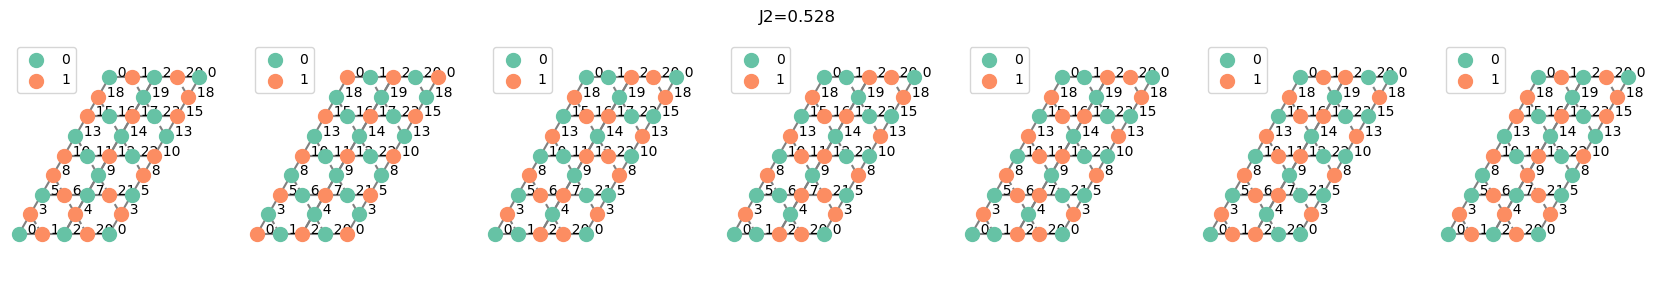

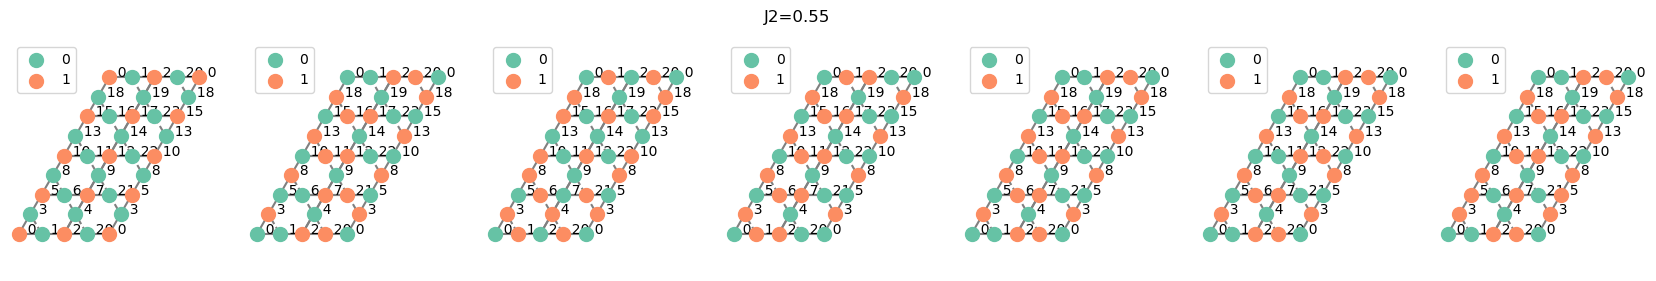

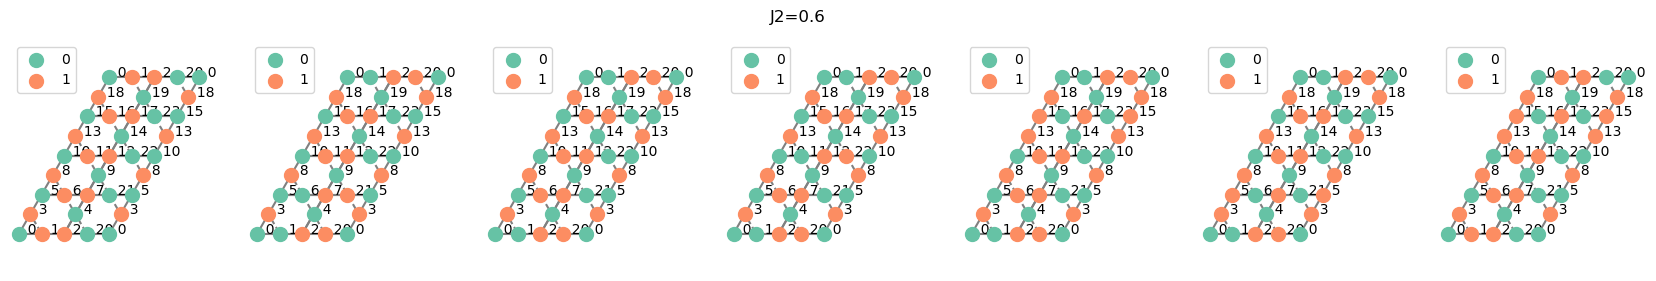

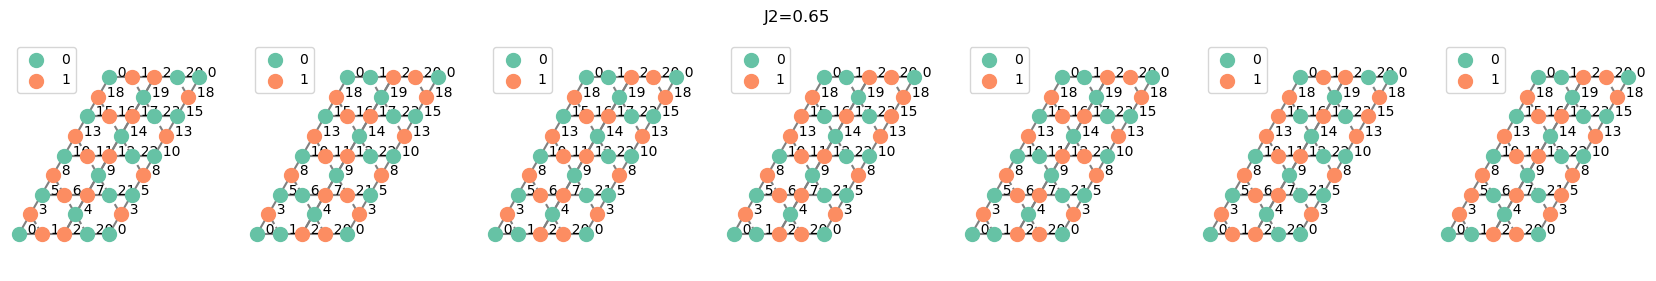

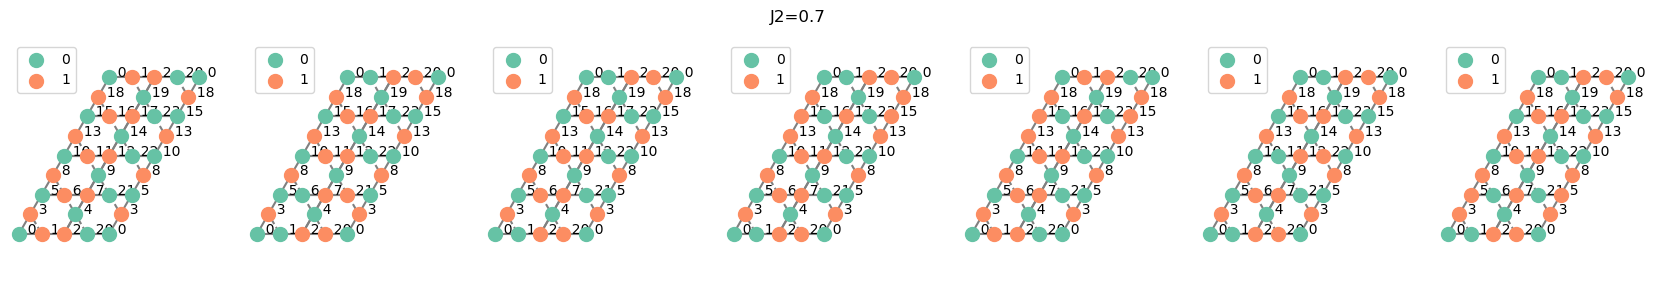

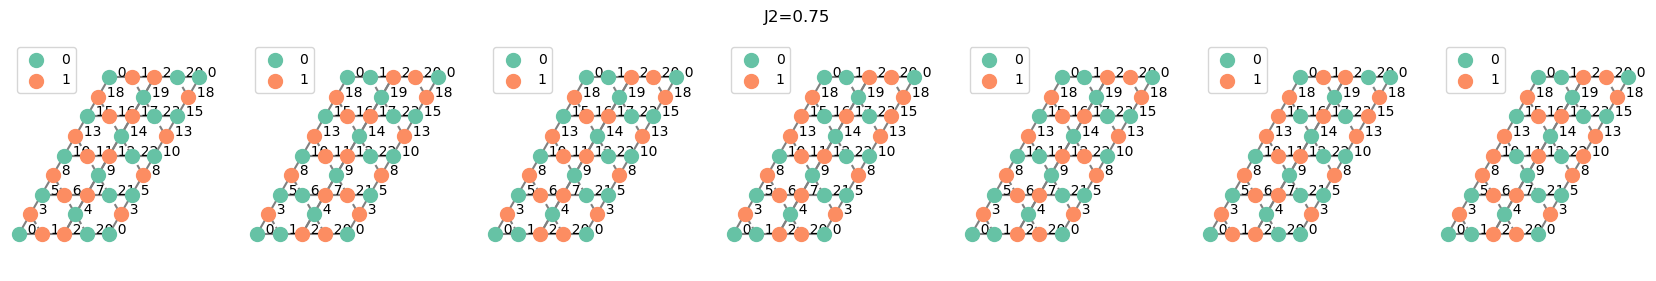

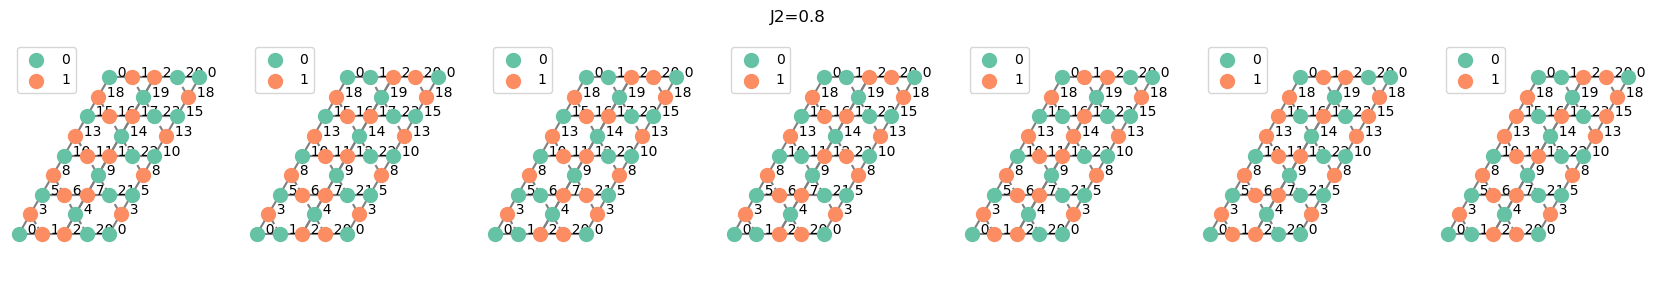

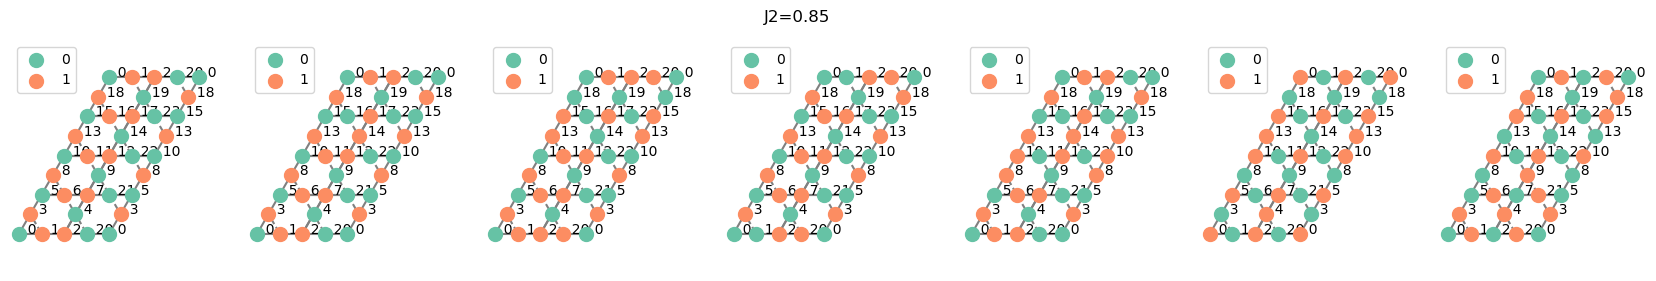

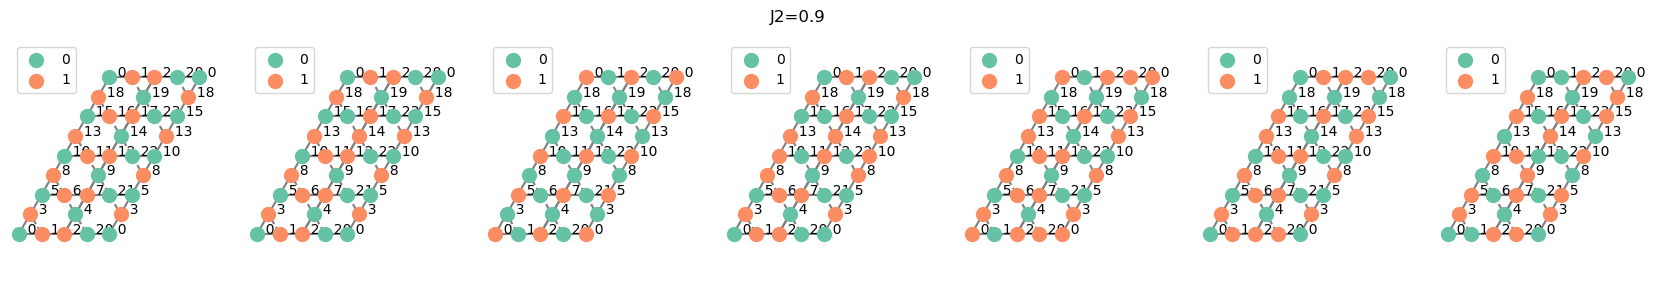

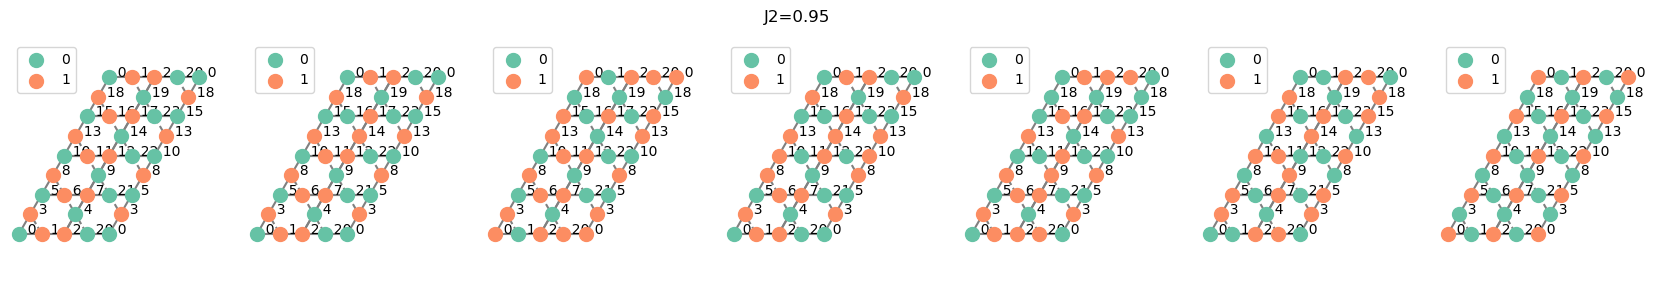

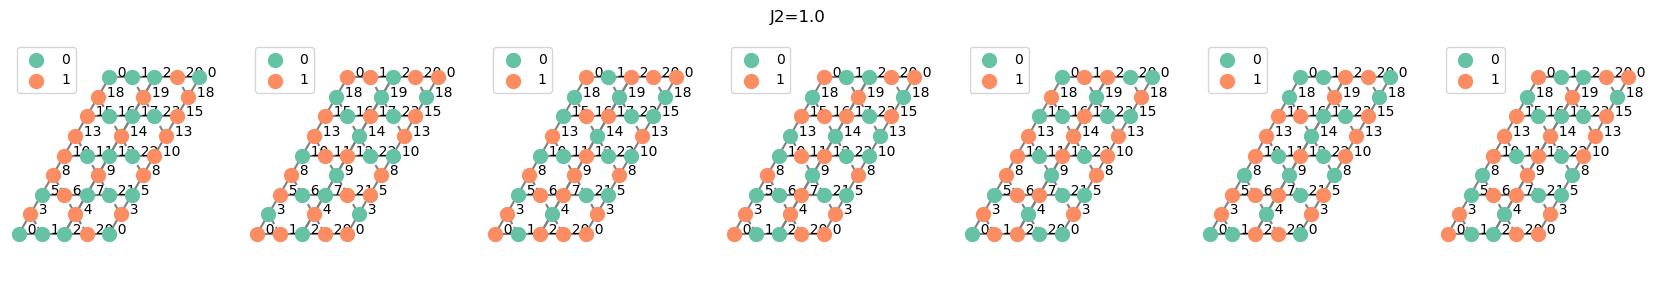

In [37]:
height = 4
# signal = "amplitude_median_bin"
max_subsets = 7
signal = "sign"
for J2, subsets in (
    analyzers_df.sort_index(level="J2")
    .xs((height, signal), level=("height", "signal_kind"))
    .assign(
        subsets=lambda df: [
            list(row["analyzer"].learner.get_coeffs_ser().iloc[: row["terms"]].index)
            for _, row in df.iterrows()
        ],
    )["subsets"]
    .items()
):
    plot_subsets(subsets[:max_subsets], KagomeLattice(width=2, height=height))
    plt.suptitle(f"J2={J2}")
    plt.show()


In [45]:
analyzers_df.loc[(4, 0.52, "sign"), "analyzer"].learner.get_coeffs_ser().index[0]


169125

In [48]:
subsets = np.asarray(
    analyzers_df.loc[(4, 0.522, "sign"), "analyzer"]
    .learner.get_coeffs_ser()
    .index[: analyzers_df.loc[(4, 0.522, "sign"), "terms"]]
)


In [52]:
popcount(subsets)

array([12,  8, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 10, 12, 12, 10,
       12, 12, 10, 10, 10, 12, 12, 10, 10, 12, 12, 12, 12, 12],
      dtype=uint8)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

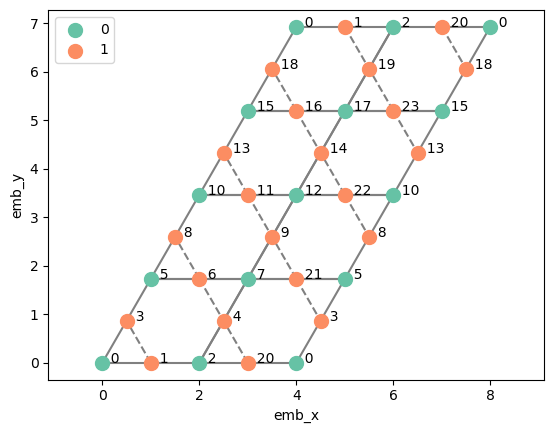

In [57]:
lattices[4].plot(spins=((2 ** 24 - 1 ) ^ 169125))


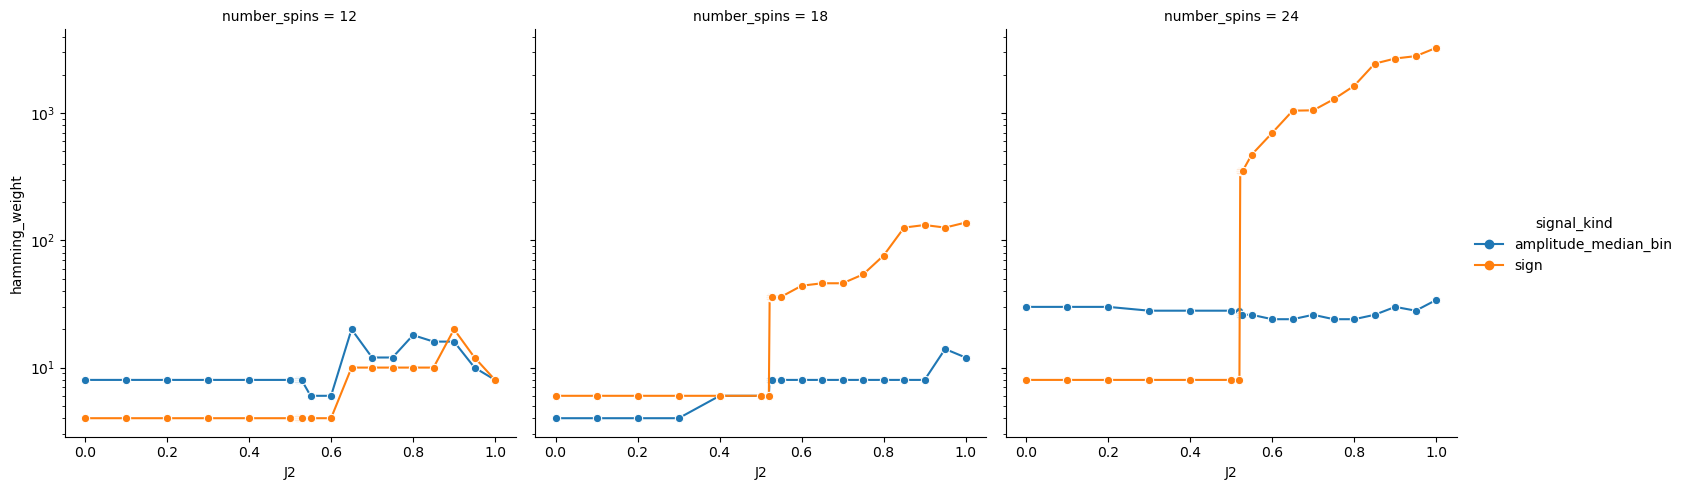

In [28]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


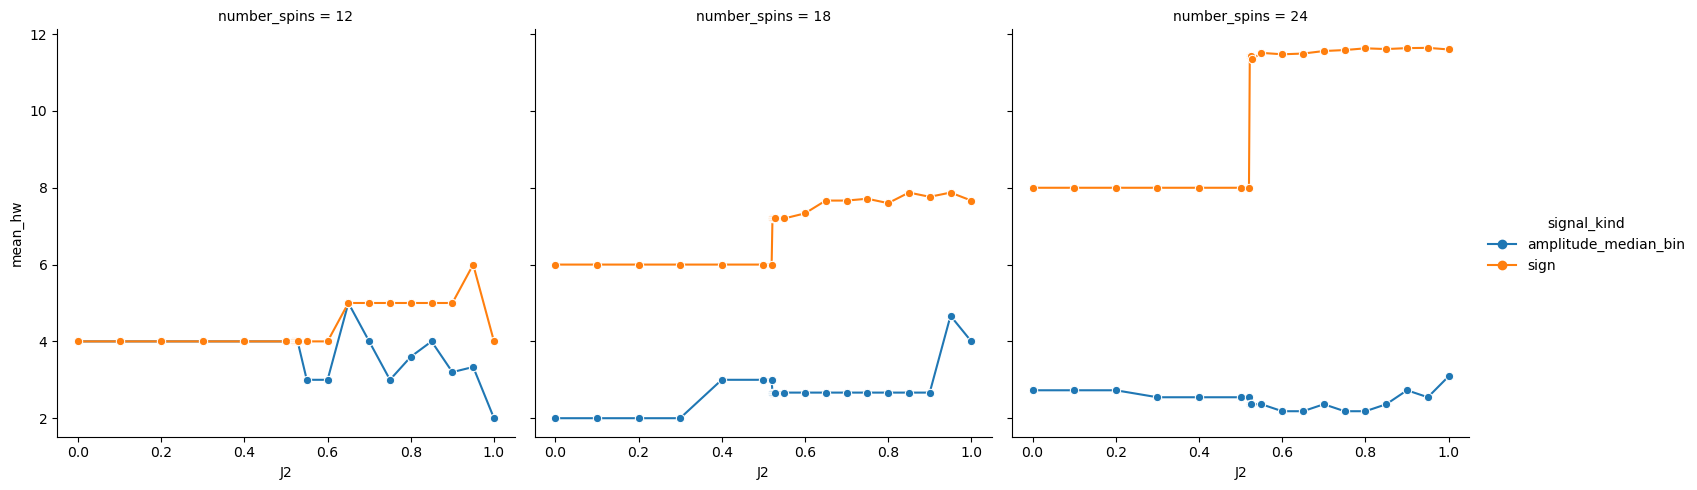

In [30]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


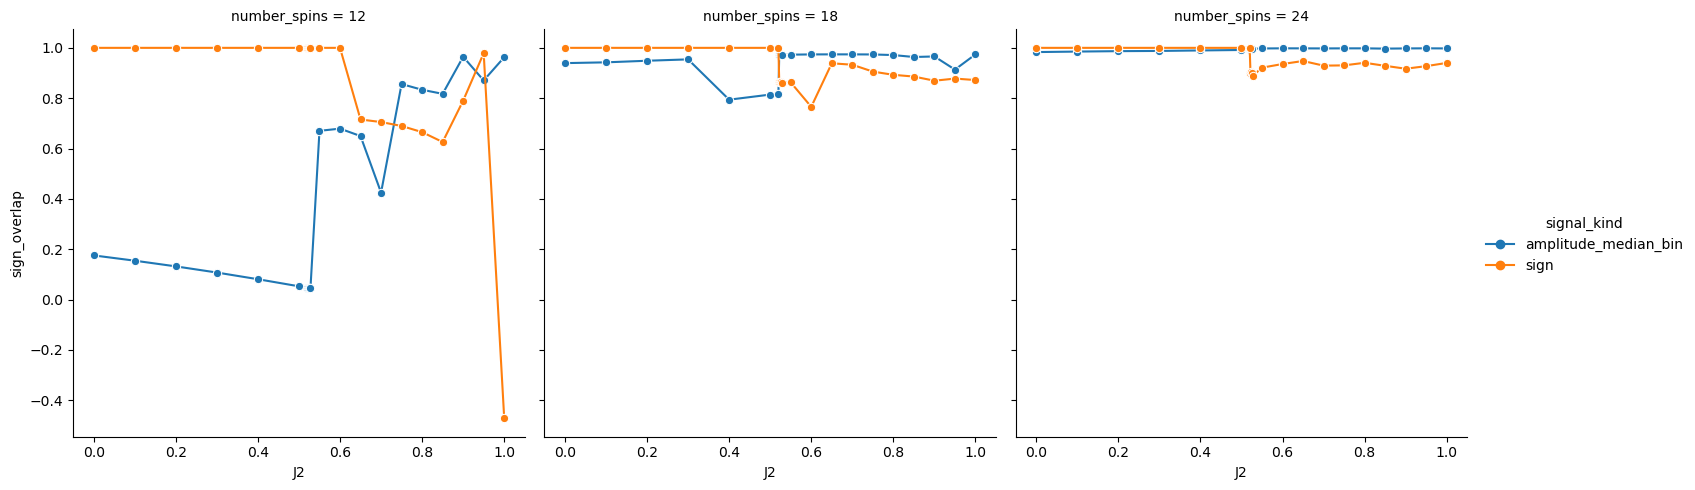

In [32]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [33]:
complexity_ratio_df = (
    analyzers_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


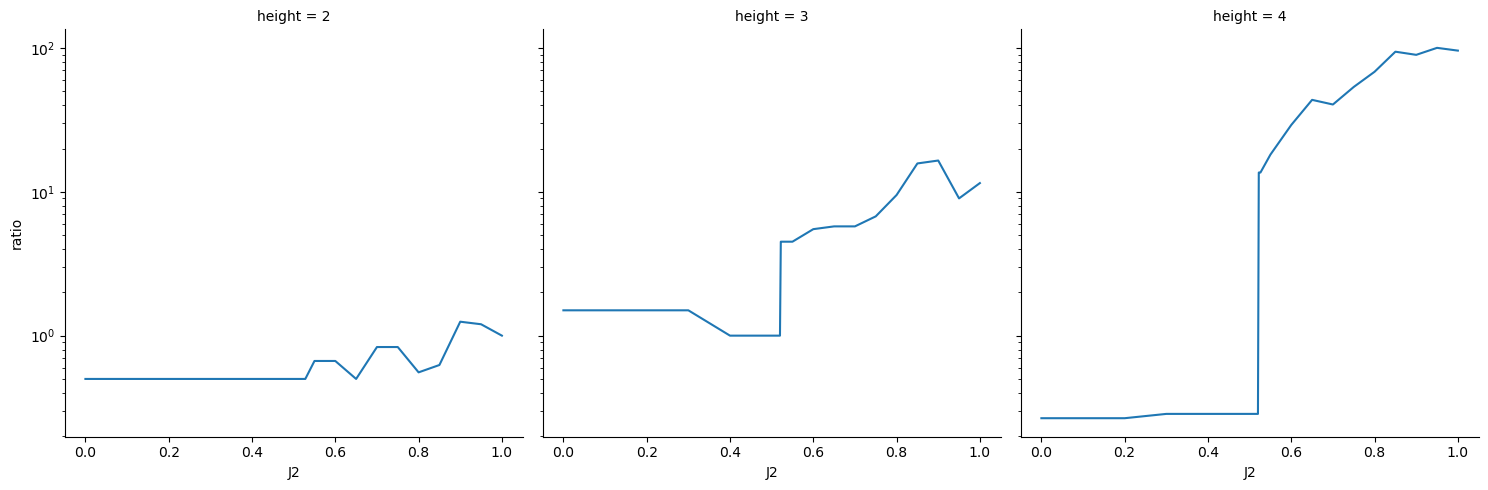

In [34]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="height", kind="line").set(yscale="log")


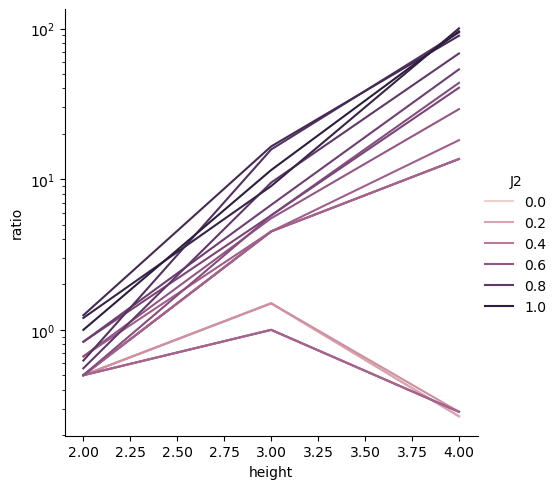

In [35]:
sns.relplot(
    complexity_ratio_df,
    x="height",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
